# Tidal Evolution Example — Moon Survival Around M-Dwarf Planets

This notebook demonstrates how to use the `secular_tides_Mdwarfs.py` module to:

✔ Run a **single tidal evolution simulation**  
✔ Plot the moon’s orbital evolution  
✔ Explore the full parameter grid in **parallel**

The code is based on **Patel, Quarles, Weinberg & Cuntz (2025)**.
It integrates the Barnes (2017) tidal model for Earth‑mass planets in M‑dwarf habitable zones.

---
## 🔧 Imports & Module Setup
Make sure the script is in the same directory as this notebook or installed as a module.


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import importlib
import secular_tides_Mdwarfs as tides  # your script renamed as a module

plt.rcParams['figure.figsize'] = (8,5)


## 🧪 Example: Run a Single Initial Condition

This runs a **single simulation**:
- Planet mass = 1.0 M⊕
- Planet semimajor axis = 0.25 AU (M2 habitable zone)
- Stellar type = M2
- Tidal lag = 698 s

The simulation returns:
- Maximum moon eccentricity
- Final moon semimajor axis (in Hill radii)
- Number of planetary orbits before instability
- Total lifetime before the moon escapes / is lost


In [28]:
# Example parameter set
m_mul = 1.0      # Planet mass in Earth masses
a_p   = 0.25     # Initial planet semimajor axis [AU]
tau_s = 698      # Tidal lag time [s]
M_star = 0.44    # M2 dwarf mass [Msun]

outname = "example_output.txt"
open(outname, "w").write("# demo output\n")

# Run one simulation and write a line of output
tides.run_sim(m_mul, a_p, tau_s, M_star, outname)

print(open(outname).read())

# demo output
1.00, 0.250, 3.077e-03, 0.388, 2.600e+07, 4.900e+06



## 📈 Plot Internal Time Evolution (Direct Integration)
To visualize the **orbit and spin evolution**, we integrate directly here rather than writing to file.

This cell uses the same tidal ODEs but stores values for plotting.

In [29]:
def integrate_for_plot(m_mul=1.0, a_p=0.25, tau_s=500, M_star=0.44, steps=600):
    """Integrate and store the internal time evolution for plotting."""
    M_p = m_mul * tides.M_E
    M_m = tides.M_MOON
    R_p = tides.R_E
    tau_p = tau_s / (3600 * 24 * 365.25)

    # Initial conditions
    rho_ratio = 5.515 / 3.34
    a_roche = 2.44 * R_p * rho_ratio**(1/3)
    a_m = 3 * a_roche
    e_m = 1e-4
    e_p = tides.EP0
    Op  = 2*np.pi / (5/(24*365.25))

    #t_eval = np.linspace(0, 2e8, steps)  # 200 Myr
    TSCALE = 2e8
    t_eval = np.concatenate((np.arange(0, 1e4, 10),np.arange(1e4,1e6,1e4),np.arange(1e6,TSCALE+1e5,1e5)))
    y0 = [a_m, e_m, a_p, e_p, Op]

    sol = solve_ivp(tides.deriv_barnes, [0, t_eval[-1]], y0, t_eval=t_eval,
                    args=(tides.KP, tau_p, M_p, R_p, M_m, M_star),
                    rtol=1e-12, atol=1e-12)
    return sol

In [30]:
sol = integrate_for_plot(m_mul,a_p,tau_s,M_star,steps=6000)
t = sol.t
am, em, ap, ep, Op = sol.y


### 📊 Orbital Evolution Plots

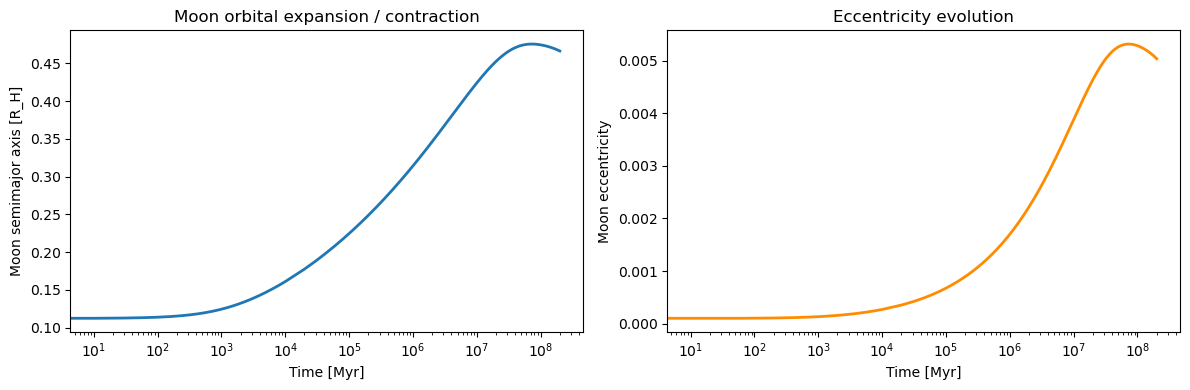

In [31]:
fig,ax = plt.subplots(1,2,figsize=(12,4))

M_p = m_mul * tides.M_E
R_H = ap*(M_p/(3*M_star))**(1./3.)
ax[0].semilogx(t, am/R_H, lw=2)
ax[0].set_xlabel("Time [Myr]")
ax[0].set_ylabel("Moon semimajor axis [R_H]")
ax[0].set_title("Moon orbital expansion / contraction")

ax[1].semilogx(t, em, lw=2, color='darkorange')
ax[1].set_xlabel("Time [Myr]")
ax[1].set_ylabel("Moon eccentricity")
ax[1].set_title("Eccentricity evolution")

plt.tight_layout()
plt.show()

## 🔁 Running a Small Grid (Parallel Example)
This demonstrates using the same worker interface as the full pipeline, but with a **small test grid** for demonstration.

⚠️ *This will produce output files in your working directory.*


In [6]:
test_params = [(1.0, ap, 500, 0.44, "grid_test.txt") for ap in np.linspace(0.17,0.35,5)]

open("grid_test.txt","w").write("# test grid output\n")

with mp.Pool(4) as pool:
    pool.map(tides.worker, test_params)

print(open("grid_test.txt").read())